# **MACHINE LEARNING**
## **SVM — Detección de URLs Spam (NLP)**

# **PASO 1: Carga del conjunto de datos**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import joblib
import os

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Importamos las librerías necesarias para el proyecto. Además de los ya habituales (`pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn`), incorporo herramientas de procesamiento de lenguaje natural:
- **NLTK**: para tokenización, stopwords y lematización.
- **TfidfVectorizer**: para convertir texto en representaciones numéricas ponderadas por relevancia.
- **SVC**: la implementación de Support Vector Machine de scikit-learn.

In [2]:
# Carga del dataset desde el repositorio del proyecto
url = "https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv"
df = pd.read_csv(url)

print(df.shape)
df.head(10)

(2999, 2)


,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True
5,https://www.brookings.edu/interactives/reopeni...,False
6,https://www.reuters.com/investigates/special-r...,False
7,https://www.theatlantic.com/magazine/archive/2...,False
8,https://www.vox.com/2020/6/17/21294680/john-bo...,False
9,https://www.theguardian.com/travel/2020/jun/18...,False


Carga del dataset directamente desde la URL proporcionada por la academia. El dataset contiene URLs etiquetadas como **spam** o **no spam**, que utilizaremos para entrenar nuestro modelo de clasificación.

# **PASO 2: Análisis Exploratorio de Datos (EDA)**

In [3]:
# Información general del dataset
print("INFORMACIÓN GENERAL")
print(df.info())
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nDescripción estadística:")
df.describe(include='all')

INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   url      2999 non-null   object
 1   is_spam  2999 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 26.5+ KB
None

Valores nulos por columna:
url        0
is_spam    0
dtype: int64

Descripción estadística:


,url,is_spam
count,2999,2999
unique,2369,2
top,https://www.bloomberg.com/tosv2.html,False
freq,26,2303


In [4]:
# Distribución de clases
print("Distribución de clases:")
print(df.iloc[:, -1].value_counts())
print(f"\nProporción spam: {df.iloc[:, -1].value_counts(normalize=True).round(3).to_dict()}")

Distribución de clases:
is_spam
False    2303
True      696
Name: count, dtype: int64

Proporción spam: {False: 0.768, True: 0.232}


In [5]:
# Crear todas las columnas estructurales
if 'url_length' not in df.columns:
    df['url_length'] = df['url'].astype(str).apply(len)
if 'num_dots' not in df.columns:
    df['num_dots'] = df['url'].astype(str).apply(lambda x: x.count('.'))
if 'num_slashes' not in df.columns:
    df['num_slashes'] = df['url'].astype(str).apply(lambda x: x.count('/'))
if 'num_digits' not in df.columns:
    df['num_digits'] = df['url'].astype(str).apply(lambda x: sum(c.isdigit() for c in x))
if 'num_special' not in df.columns:
    df['num_special'] = df['url'].astype(str).apply(lambda x: sum(c in '?=&%@#-_~' for c in x))

Distribución de clases:
is_spam
False    2303
True      696
Name: count, dtype: int64

Proporción spam: {False: 0.768, True: 0.232}


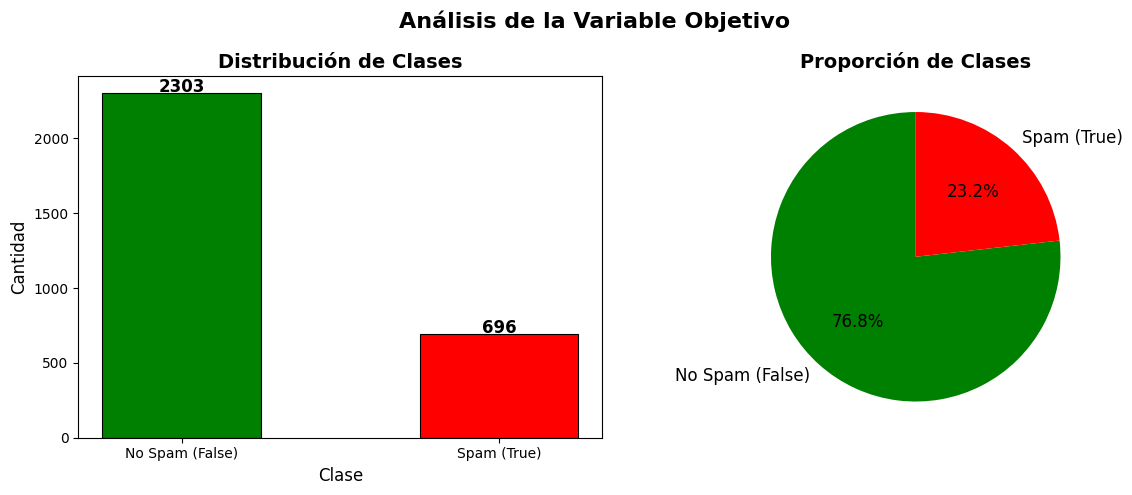

In [6]:
# Distribución de clases
print("Distribución de clases:")
print(df['is_spam'].value_counts())
print(f"\nProporción spam: {df['is_spam'].value_counts(normalize=True).round(3).to_dict()}")

class_counts = df['is_spam'].value_counts()
labels = ['No Spam (False)', 'Spam (True)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barras
axes[0].bar(labels,
            class_counts.values,
            color=['green', 'red'],
            edgecolor='black',
            linewidth=0.8,
            width=0.5)
axes[0].set_title('Distribución de Clases', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)

# Pie
axes[1].pie(class_counts.values,
            labels=labels,
            autopct='%1.1f%%',
            colors=['green', 'red'],
            startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.suptitle('Análisis de la Variable Objetivo', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Analisis de la distribución de la variable objetivo para identificar si existe desbalanceo de clases. Un dataset desbalanceado puede afectar al rendimiento del modelo.

No Spam: 2303 filas — Spam: 696 filas


/tmp/ipykernel_2372/1248973527.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([no_spam, spam],


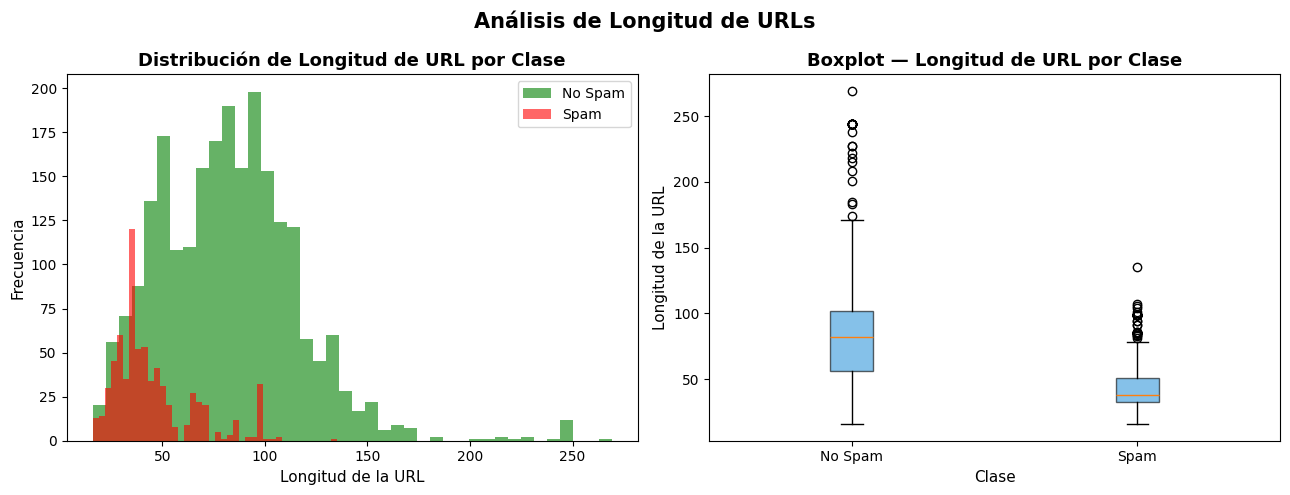

          count   mean    std   min   25%   50%    75%    max
is_spam                                                      
False    2303.0  82.13  34.14  16.0  56.0  82.0  102.0  269.0
True      696.0  44.82  20.15  16.0  33.0  38.0   51.0  135.0


In [7]:
no_spam = df[df['is_spam'] == False]['url_length']
spam    = df[df['is_spam'] == True]['url_length']

print(f"No Spam: {len(no_spam)} filas — Spam: {len(spam)} filas")  # verificación

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma
axes[0].hist(no_spam,
             bins=40,
             alpha=0.6,
             label='No Spam',
             color='green')
axes[0].hist(spam,
             bins=40,
             alpha=0.6,
             label='Spam',
             color='red')
axes[0].set_title('Distribución de Longitud de URL por Clase', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Longitud de la URL', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].legend()

# Boxplot
axes[1].boxplot([no_spam, spam],
                labels=['No Spam', 'Spam'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[1].set_title('Boxplot — Longitud de URL por Clase', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Clase', fontsize=11)
axes[1].set_ylabel('Longitud de la URL', fontsize=11)

plt.suptitle('Análisis de Longitud de URLs', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(df.groupby('is_spam')['url_length'].describe().round(2))

La longitud de la URL puede ser una señal relevante: las URLs spam suelen ser más largas o seguir patrones distintos a las URLs legítimas. Este análisis preliminar nos ayuda a entender si existe esta diferencia en el dataset.

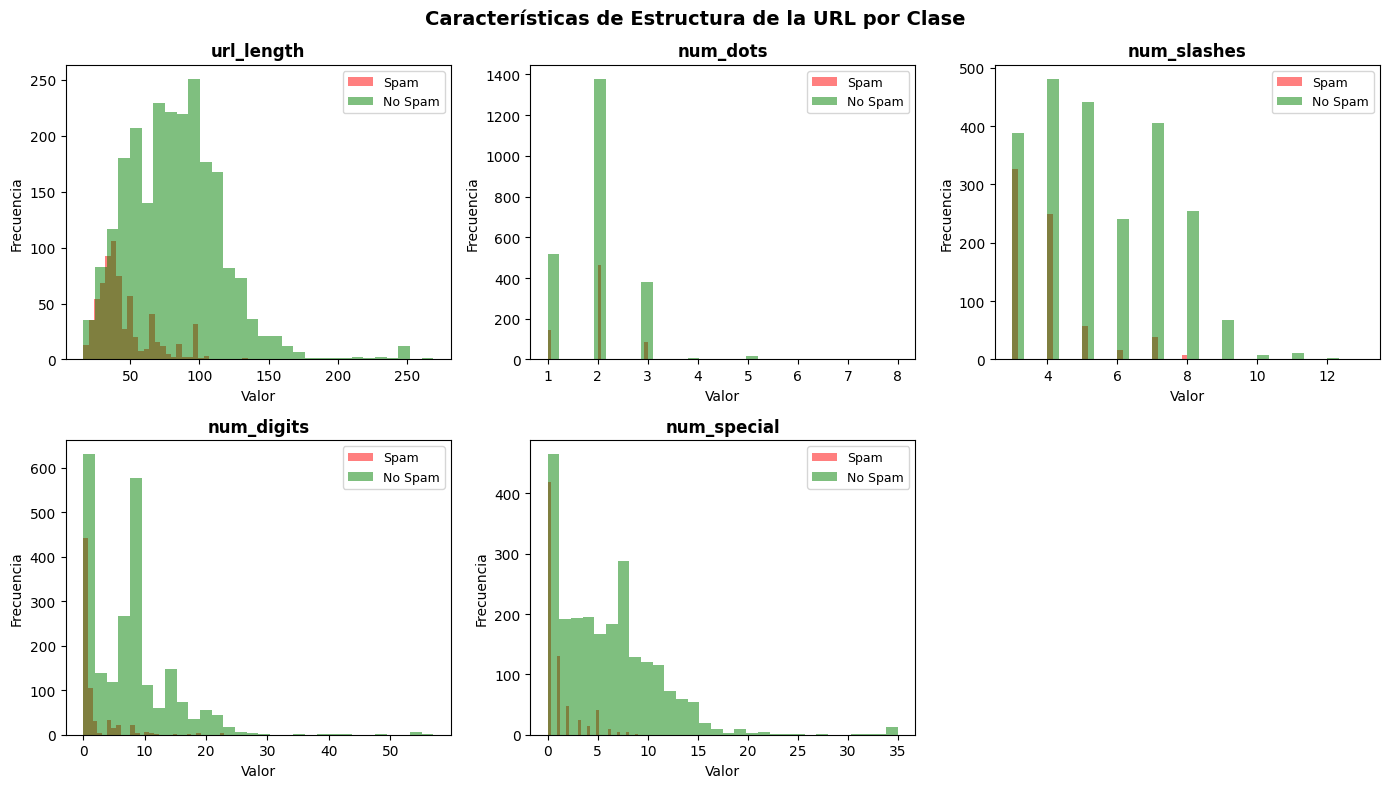

In [8]:
feature_cols = ['url_length', 'num_dots', 'num_slashes', 'num_digits', 'num_special']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    for label, color in [(True, 'red'), (False, 'green')]:
        axes[i].hist(df[df['is_spam'] == label][col],
                     bins=30,
                     alpha=0.5,
                     label='Spam' if label else 'No Spam', color=color)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor', fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=10)
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)

plt.suptitle('Características de Estructura de la URL por Clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Extraemos features estructurales de las URLs: número de puntos, barras, dígitos y caracteres especiales. Estas características numéricas complementan el análisis del texto y revelan patrones que diferencian URLs validas de spam.

# **PASO 3: Preprocesamiento de URLs**

In [10]:
stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess_url(url):
    """
    Preprocesa una URL para su uso en NLP:
    1. Convierte a minúsculas.
    2. Elimina el protocolo (http/https/ftp).
    3. Segmenta según signos de puntuación y separadores.
    4. Filtra stopwords y tokens muy cortos.
    5. Lematiza cada token.
    """
    url = str(url).lower()
    # Eliminar protocolo
    url = re.sub(r'https?://|ftp://', '', url)
    # Segmentar por caracteres no alfanuméricos
    tokens = re.split(r'[\W_]+', url)
    # Filtrar y lematizar
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok and len(tok) > 1 and tok not in stop_words
    ]
    return ' '.join(tokens)

# Aplicar preprocesamiento
df['processed_url'] = df['url'].apply(preprocess_url)

# Verificar resultado
print("Ejemplos de preprocesamiento:")
for i in range(5):
    print(f"Original : {df['url'].iloc[i]}")
    print(f"Procesada: {df['processed_url'].iloc[i]}")


Ejemplos de preprocesamiento:
Original : https://briefingday.us8.list-manage.com/unsubscribe
Procesada: briefingday us8 list manage com unsubscribe
Original : https://www.hvper.com/
Procesada: www hvper com
Original : https://briefingday.com/m/v4n3i4f3
Procesada: briefingday com v4n3i4f3
Original : https://briefingday.com/n/20200618/m#commentform
Procesada: briefingday com 20200618 commentform
Original : https://briefingday.com/fan
Procesada: briefingday com fan


La función `preprocess_url` aplica la pipeline de NLP completa sobre cada URL:
- **Lowercase**: normaliza el texto para evitar que `Google` y `google` sean tratadas como palabras distintas.
- **Eliminación de protocolo**: `https://` no aporta información discriminativa.
- **Segmentación por puntuación**: separa los componentes de la URL (`www`, nombre de dominio, ruta, parámetros) en tokens individuales.
- **Filtrado de stopwords**: elimina palabras vacías del inglés.
- **Lematización**: reduce cada token a su forma base (`running` → `run`).

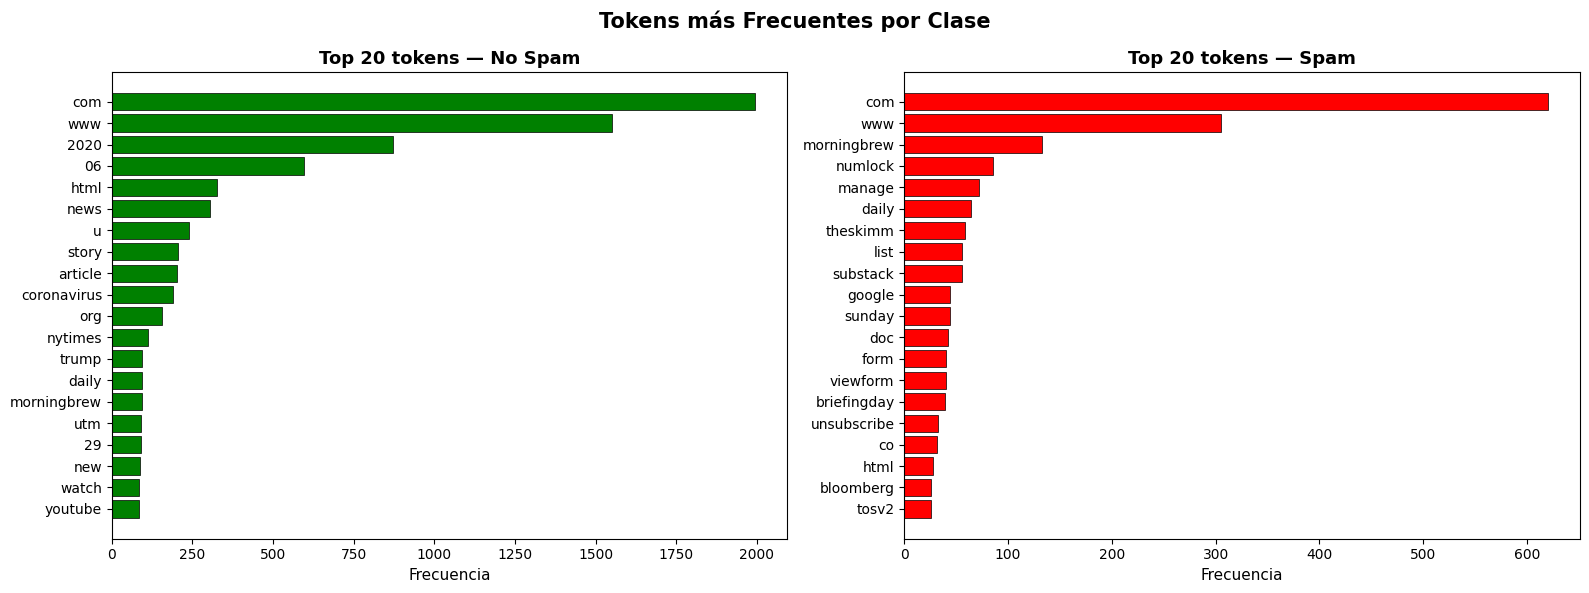

In [11]:
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (label, color, nombre) in zip(axes, [
    (False, 'green', 'No Spam'),
    (True,  'red', 'Spam')
]):
    subset_text = ' '.join(df[df['is_spam'] == label]['processed_url'])
    word_counts = Counter(subset_text.split()).most_common(20)
    words, counts = zip(*word_counts)
    ax.barh(list(words)[::-1], list(counts)[::-1],
            color=color,
            edgecolor='black',
            linewidth=0.5)
    ax.set_title(f'Top 20 tokens — {nombre}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frecuencia', fontsize=11)

plt.suptitle('Tokens más Frecuentes por Clase', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Analizamos los tokens más frecuentes en cada clase despues del preprocesamiento. Esto permite identificar si existen palabras clave que aparecen más en URLs spam (por ejemplo, términos relacionados con phishing, sorteos o dominios sospechosos) frente a las URLs legítimas.

In [12]:
# Separar features y target
X = df['processed_url']
y = df['is_spam']

# División en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño del conjunto de entrenamiento : {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba        : {X_test.shape[0]} muestras")
print(f"Proporción train/test                : 80% / 20%")

Tamaño del conjunto de entrenamiento : 2399 muestras
Tamaño del conjunto de prueba        : 600 muestras
Proporción train/test                : 80% / 20%


Divido el dataset en **80% entrenamiento** y **20% prueba**, usando `stratify=y` para mantener la misma proporción de clases en ambos conjuntos. Esto es importante cuando existen desbalances en los datos.**texto en negrita**

# **PASO 4: Construcción del SVM (parámetros por defecto)**

In [13]:
# Pipeline: TF-IDF + SVM con parámetros por defecto
pipeline_base = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        sublinear_tf=True
    )),
    ('svm', SVC(random_state=42))
])

# Entrenamiento
pipeline_base.fit(X_train, y_train)

# Predicciones
y_pred_base = pipeline_base.predict(X_test)

print("RESULTADOS — SVM (parámetros por defecto)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base))

RESULTADOS — SVM (parámetros por defecto)
Accuracy: 0.9617

Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.99      0.98       461
        True       0.97      0.86      0.91       139

    accuracy                           0.96       600
   macro avg       0.96      0.93      0.94       600
weighted avg       0.96      0.96      0.96       600



Construyo una **Pipeline** que encadena dos pasos:
1. **TF-IDF Vectorizer**: transforma las URLs preprocesadas en vectores numéricos. Luego uso `ngram_range=(1,2)` para capturar también bigramas y `sublinear_tf=True` para aplicar escala logarítmica a las frecuencias.
2. **SVC**: el clasificador SVM con kernel RBF y parámetros por defecto (`C=1.0`, `gamma='scale'`).

El uso de pipelines garantiza que el vectorizador se ajuste sobre datos de entrenamiento, evitando así data leakage.

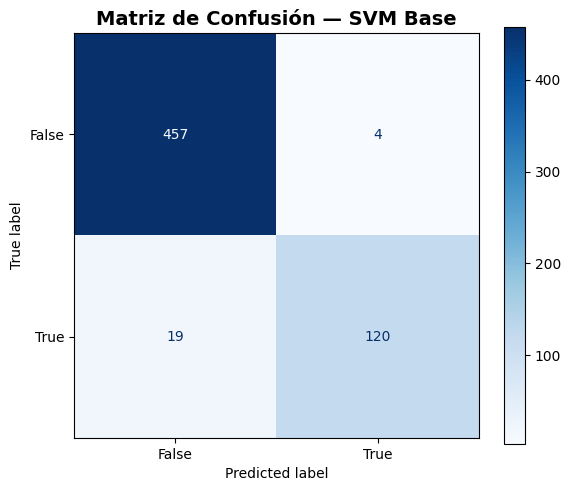

In [14]:
# Matriz de confusión — modelo base
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_base,
    cmap='Blues',
    ax=ax
)
ax.set_title('Matriz de Confusión — SVM Base', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

La **matriz de confusión** permite ver detalladamente qué errores está cometiendo el modelo:
- **Falsos Positivos** (FP): URLs legítimas clasificadas como spam — son molestos pero no críticos.
- **Falsos Negativos** (FN): URLs spam que pasan desapercibidas — son más conflictivas en un sistema de detección real.

Esta distinción justificará que en la optimización hay que prestar mucha atención al **recall** de la clase spam.

> Añadir blockquote






In [15]:
# Validación cruzada del modelo base
cv_scores_base = cross_val_score(pipeline_base, X, y, cv=5, scoring='accuracy')

print("Validación cruzada (5-fold) — SVM Base:")
print(f"  Scores  : {cv_scores_base.round(4)}")
print(f"  Media   : {cv_scores_base.mean():.4f}")
print(f"  Std     : {cv_scores_base.std():.4f}")

Validación cruzada (5-fold) — SVM Base:
  Scores  : [0.9767 0.9567 0.9333 0.9433 0.8815]
  Media   : 0.9383
  Std     : 0.0319


Complemento la evaluación con **validación cruzada de 5 pliegues** para obtener una estimación más fuerte del rendimiento del modelo, menos dependiente de cómo se haya realizado la partición train/test.

# **PASO 5: Optimización del modelo (Grid Search)**

In [16]:
# Defino la grilla de hiperparámetros
param_grid = {
    'tfidf__max_features'  : [5000, 10000],
    'tfidf__ngram_range'   : [(1, 1), (1, 2)],
    'svm__C'               : [0.1, 1, 10],
    'svm__kernel'          : ['linear', 'rbf'],
    'svm__gamma'           : ['scale', 'auto']
}

# Pipeline base sobre la que hacer el search
pipeline_opt = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('svm', SVC(random_state=42))
])

grid_search = GridSearchCV(
    pipeline_opt,
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nMejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print(f"\nMejor F1 (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Mejores hiperparámetros encontrados:
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf', 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}

Mejor F1 (CV): 0.9621


Aplico **Grid Search con validación cruzada de 5 pliegues** para explorar el espacio de hiperparámetros:
- **`C`**: controla el trade-off entre margen amplio y clasificación correcta de los puntos de entrenamiento. Valores bajos nos da mayor margen, mayor tolerancia a errores (Soft Margin); valores altos nos da menor margen, menos errores en train (riesgo de sobreajuste).
- **`kernel`**: función que transforma los datos a un espacio de mayor dimensión. `rbf` es el más versátil; `linear` es más fácil de interpretar y rápido.
- **`gamma`**: controla la influencia de cada muestra en el límite de decisión (solo para kernels no lineales).
- **`max_features` / `ngram_range`**: parámetros del TF-IDF que controlan el vocabulario utilizado.

Uso `f1_weighted` como métrica de optimización para ponderar precision y recall de forma más equilibrada.

In [17]:
# Evaluación del modelo optimizado
best_model = grid_search.best_estimator_
y_pred_opt = best_model.predict(X_test)

print("RESULTADOS — SVM OPTIMIZADO")
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_opt))

RESULTADOS — SVM OPTIMIZADO
Accuracy: 0.9683

Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.99      0.98       461
        True       0.96      0.90      0.93       139

    accuracy                           0.97       600
   macro avg       0.97      0.94      0.95       600
weighted avg       0.97      0.97      0.97       600



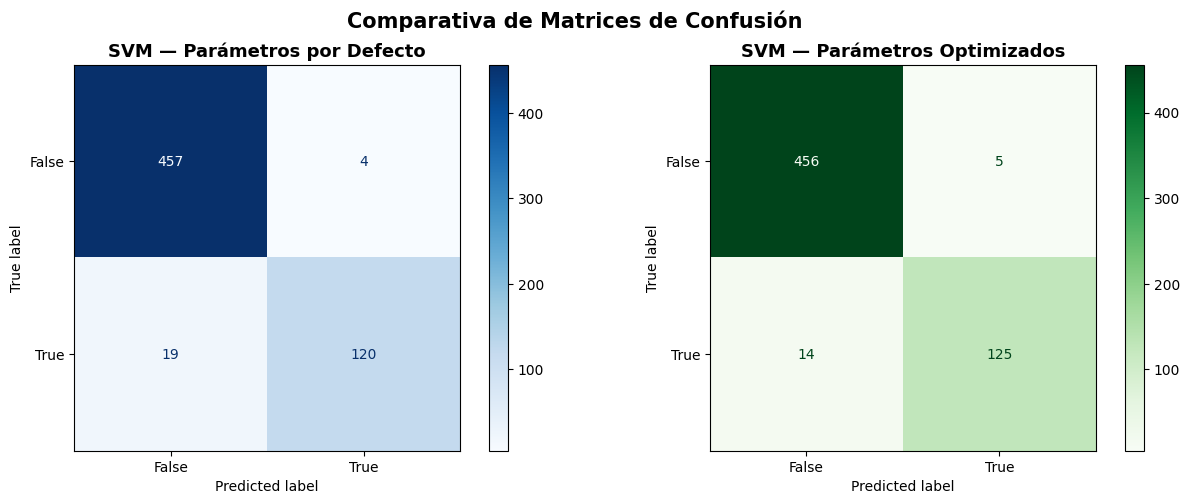

In [18]:
# Comparativa visual: modelos base vs optimizado
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_base,
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('SVM — Parámetros por Defecto', fontsize=13, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_opt,
    cmap='Greens', ax=axes[1]
)
axes[1].set_title('SVM — Parámetros Optimizados', fontsize=13, fontweight='bold')

plt.suptitle('Comparativa de Matrices de Confusión', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Comparo visualmente las matrices de confusión del modelo base y el optimizado. La mejora esperada tras el Grid Search se refleja en la reducción de los falsos negativos (URLs spam no detectadas), que representan el riesgo más alto en un sistema de filtrado real.

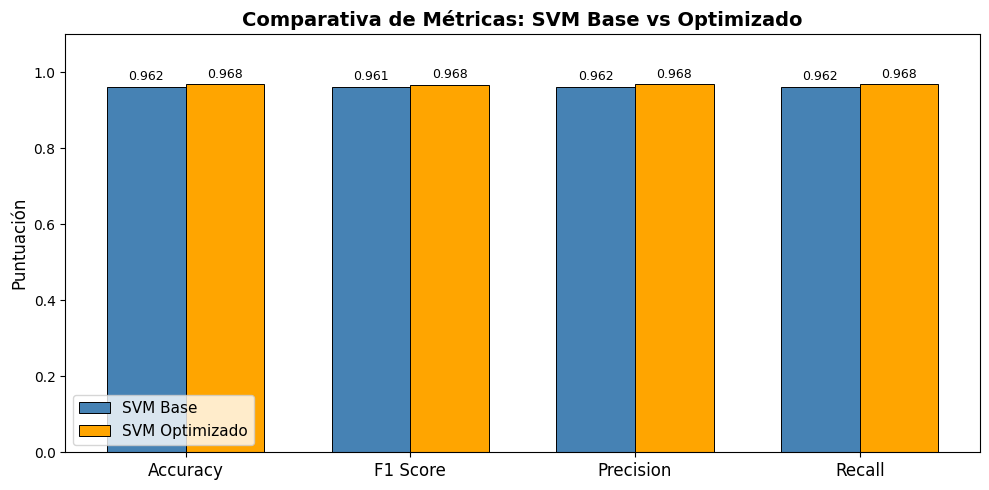


Tabla de métricas:
                Accuracy  F1 Score  Precision  Recall
SVM Base          0.9617    0.9609     0.9619  0.9617
SVM Optimizado    0.9683    0.9680     0.9682  0.9683


In [19]:
# Resumen comparativo de métricas
acc_base = accuracy_score(y_test, y_pred_base)
acc_opt  = accuracy_score(y_test, y_pred_opt)

from sklearn.metrics import f1_score, precision_score, recall_score

metrics = {
    'Accuracy' : [acc_base, acc_opt],
    'F1 Score' : [f1_score(y_test, y_pred_base, average='weighted'),
                  f1_score(y_test, y_pred_opt,  average='weighted')],
    'Precision': [precision_score(y_test, y_pred_base, average='weighted', zero_division=0),
                  precision_score(y_test, y_pred_opt,  average='weighted', zero_division=0)],
    'Recall'   : [recall_score(y_test, y_pred_base, average='weighted'),
                  recall_score(y_test, y_pred_opt,  average='weighted')]
}

metrics_df = pd.DataFrame(metrics, index=['SVM Base', 'SVM Optimizado'])

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics))
width = 0.35
bars1 = ax.bar(x - width/2,
               metrics_df.iloc[0],
               width,
               label='SVM Base',
               color='steelblue',
               edgecolor='black',
               linewidth=0.7)
bars2 = ax.bar(x + width/2,
               metrics_df.iloc[1],
               width,
               label='SVM Optimizado',
               color='orange',
               edgecolor='black',
               linewidth=0.7)

ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(metrics.keys(), fontsize=12)
ax.set_ylabel('Puntuación', fontsize=12)
ax.set_title('Comparativa de Métricas: SVM Base vs Optimizado', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTabla de métricas:")
print(metrics_df.round(4))

El gráfico comparativo resume la mejora obtenida tras optimizar los hiperparámetros. En problemas de detección de spam, el **F1 Score** y el **Recall** son muy relevantes porque capturan mejor el rendimiento en ambas clases, incluyendo la capacidad del modelo para detectar efectivamente los casos de spam.

# **PASO 6: Guardado del modelo**

In [20]:
# Crear carpeta de modelos si no existe
os.makedirs('../models', exist_ok=True)

# Guardar el modelo optimizado
model_path = '../models/svm_url_spam_model.pkl'
joblib.dump(best_model, model_path)
print(f"Modelo guardado correctamente en: {model_path}")

# Verificar que se puede cargar
loaded_model = joblib.load(model_path)
y_pred_loaded = loaded_model.predict(X_test[:5])
print(f"\nVerificación de carga — primeras 5 predicciones: {y_pred_loaded}")
print(f"Etiquetas reales                               : {y_test.iloc[:5].values}")

Modelo guardado correctamente en: ../models/svm_url_spam_model.pkl

Verificación de carga — primeras 5 predicciones: [False False False False  True]
Etiquetas reales                               : [False False False False  True]


Guardo el modelo optimizado completo usando `joblib`. Esto nos permite:
- **Reutilizarlo** en producción sin necesidad de reentrenar.
- **Compartirlo** fácilmente cargándolo con una sola línea: `joblib.load('ruta/modelo.pkl')`.
- **Garantizar consistencia**: al guardar la Pipeline completa, el preprocesamiento y el modelo se aplican siempre juntos, evitando así errores de transformación en futuros nuevos datos.

# **CONCLUSIONES**

En este proyecto he creado un **sistema de detección de URLs spam** combinando Procesamiento de Lenguaje Natural (NLP) con Support Vector Machines (SVM).


### 1. Carga y exploración del dataset
Este proyecto consta de un dataset de **2.999 URLs** etiquetadas como spam (696) o legítimas (2.303),
lo que reveló un **desbalanceo de clases de aproximadamente 1:3**.

### 2. Análisis Exploratorio (EDA)
Más allá de las clases, analicé características estructurales de las URLs: longitud, número de puntos, barras, dígitos y caracteres especiales.

Este análisis nos mostró que las URLs spam tienden a ser más largas y con más caracteres especiales, lo que tiene sentido intuitivamente — las URLs maliciosas suelen incluir parámetros codificados, subdominios
extra para ocultar su destino real.

### 3. Preprocesamiento NLP
Apliqué una pipeline completa sobre cada URL:
- **Eliminación del protocolo** (`https://`) — no aporta información discriminativa.
- **Tokenización por puntuación** — separa los componentes de la URL en tokens individuales.
- **Filtrado de stopwords** — elimina palabras vacías en inglés.
- **Lematización** — reduce cada token a su forma base.

Este paso es muy importante en el proyecto: transforma texto crudo en una representación que el modelo puede aprender.

### 4. TF-IDF + SVM
He usado una **Pipeline de scikit-learn** que encadena el vectorizador TF-IDF con el clasificador SVM. El uso de pipelines es una buena práctica porque garantiza que el ectorizador se ajuste **solo sobre datos de entrenamiento**, evitando data leakage.

El SVM es adecuado para clasificación de texto porque:
- Funciona bien en espacios de **alta dimensionalidad** (miles de tokens).
- Es robusto cuando hay más features que muestras.
- El kernel RBF nos permite separar clases que no son linealmente separables.

### 5. Optimización con Grid Search
Exploración sistemáticamente combinaciones de hiperparámetros (`C`, `kernel`, `gamma`, `ngram_range`) usando validación cruzada de 5 pliegues, optimizando el **F1 Score ponderado** — más apropiado que el accuracy en datasets desbalanceados.

### 6. Persistencia del modelo
Guardamos la Pipeline completa con `joblib`, lo que permite reutilizar tanto el
vectorizador como el clasificador en producción sin necesidad de reentrenar.
